# Student Score Prediction & Feature Impact Analysis
> **Tools:** Python | Pandas | NumPy | Matplotlib | Seaborn | Scikit-learn  

---

##  Executive Summary
This notebook demonstrates a end-to-end Machine Learning pipeline to predict high school students' final exam scores (`Exam_Score`). We perform exploratory data analysis, handle missing values, engineer categorical encodings, build a baseline **Simple Linear Regression** model, and evaluate performance using standard metrics ($\text{MAE}$, $\text{MSE}$, $\text{RMSE}$, $R^2$). 

Furthermore, we explore **Bonus Objectives**:
1. Comparing Simple Linear Regression against **Polynomial Regression** (Degree 2 & 3).
2. Experimenting with **Multiple Linear Regression** by incorporating habits like sleep hours, attendance, parental involvement, and tutoring.

## 1. Environment Setup

In [1]:
# ==========================================
# 1. Environment Setup & Library Imports
# ==========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Styling configurations for visualizations
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

import warnings
warnings.filterwarnings('ignore')

print("Libraries successfully loaded!")

Libraries successfully loaded!


## 2. Dataset Loading & Initial Inspection
We load the dataset using `pandas` and inspect structural properties, data types, and initial records.

In [2]:
# Load the dataset (Adjust file path if using local or Kaggle environment)
try:
    df = pd.read_csv('/kaggle/input/datasets/mobeenfatimah/student-exam-performance-and-success-dataset/student_exam_performance.csv')
except FileNotFoundError:
    # Alternative path fallback
    df = pd.read_csv('StudentPerformanceFactors.csv')

print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")
df.head()

Dataset Shape: 100000 rows, 44 columns



,student_id,age,gender,education_level,school_type,family_income,parent_education,urban_rural,previous_exam_score,previous_gpa,...,exam_difficulty,exam_preparation_days,questions_attempted,questions_correct,time_management_score,exam_anxiety_level,exam_score,performance_grade,pass_status,performance_level
0,STU_000001,20,Female,High School,Public,Middle,NaN,Rural,78.36,2.95,...,Medium,27,95,86,NaN,9.39,90.40,A,Pass,High
1,STU_000002,17,Male,High School,Public,Middle,NaN,Suburban,73.40,2.89,...,Easy,4,100,86,87.17,6.31,86.21,A,Pass,High
2,STU_000003,18,Other,Undergraduate,Public,Middle,Master,Urban,82.76,3.35,...,Easy,28,96,74,63.77,9.87,76.11,B,Pass,Medium
3,STU_000004,20,Male,High School,Public,Middle,High School,Suburban,60.61,2.57,...,Medium,16,97,77,59.51,9.68,79.74,B,Pass,Medium
4,STU_000005,16,Female,High School,Private,High,Bachelor,Suburban,74.79,2.84,...,Medium,28,98,52,84.64,10.00,50.66,D,Pass,Low


## 3. Data Cleaning & Preprocessing
Data quality directly governs model accuracy. Here, we:
- Identify missing (`NaN`) values and impute or drop them.
- Check for duplicate entries.
- Verify target variable distribution (`Exam_Score`).

In [3]:
# Inspect missing values
print("--- Missing Values Count ---")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Clean missing values: Impute numerical with median, categorical with mode
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype == 'object':
            df[col].fillna(df[col].mode()[0], inplace=True)
        else:
            df[col].fillna(df[col].median(), inplace=True)

# Remove duplicate rows if any exist
duplicates = df.duplicated().sum()
if duplicates > 0:
    df.drop_duplicates(inplace=True)
    print(f"\nRemoved {duplicates} duplicate records.")

print(f"\nCleaned Dataset Shape: {df.shape}")

--- Missing Values Count ---
parent_education         6526
previous_gpa             7793
attendance_percentage    9863
notes_quality            8407
sleep_quality            6994
device_availability      2965
time_management_score    9613
dtype: int64

Cleaned Dataset Shape: (100000, 44)


## 4. Exploratory Data Analysis (EDA)
Understanding the key relationships between features—specifically `Hours_Studied`, `Attendance`, `Sleep_Hours` and final `Exam_Score`.

In [4]:
# Check exact column names
print("Columns in DataFrame:")
print(df.columns.tolist())

Columns in DataFrame:
['student_id', 'age', 'gender', 'education_level', 'school_type', 'family_income', 'parent_education', 'urban_rural', 'previous_exam_score', 'previous_gpa', 'attendance_percentage', 'assignment_completion_rate', 'class_participation', 'study_hours_per_day', 'self_study_hours', 'private_tuition', 'online_learning_hours', 'study_consistency', 'study_environment', 'study_method', 'revision_frequency', 'practice_tests_completed', 'notes_quality', 'sleep_hours', 'sleep_quality', 'daily_screen_time', 'physical_activity_hours', 'break_frequency', 'stress_level', 'motivation_level', 'internet_access', 'device_availability', 'educational_app_usage', 'online_course_hours', 'exam_difficulty', 'exam_preparation_days', 'questions_attempted', 'questions_correct', 'time_management_score', 'exam_anxiety_level', 'exam_score', 'performance_grade', 'pass_status', 'performance_level']


In [5]:
# Strip leading/trailing spaces from column names
df.columns = df.columns.str.strip()

# Verify target column presence
if 'Exam_Score' not in df.columns:
    # Print potential matching columns if naming differs
    possible_targets = [c for c in df.columns if 'score' in c.lower() or 'exam' in c.lower()]
    print(f"Target column 'Exam_Score' not found. Did you mean: {possible_targets}?")
else:
    print("Column 'Exam_Score' found successfully!")

Target column 'Exam_Score' not found. Did you mean: ['previous_exam_score', 'exam_difficulty', 'exam_preparation_days', 'time_management_score', 'exam_anxiety_level', 'exam_score']?


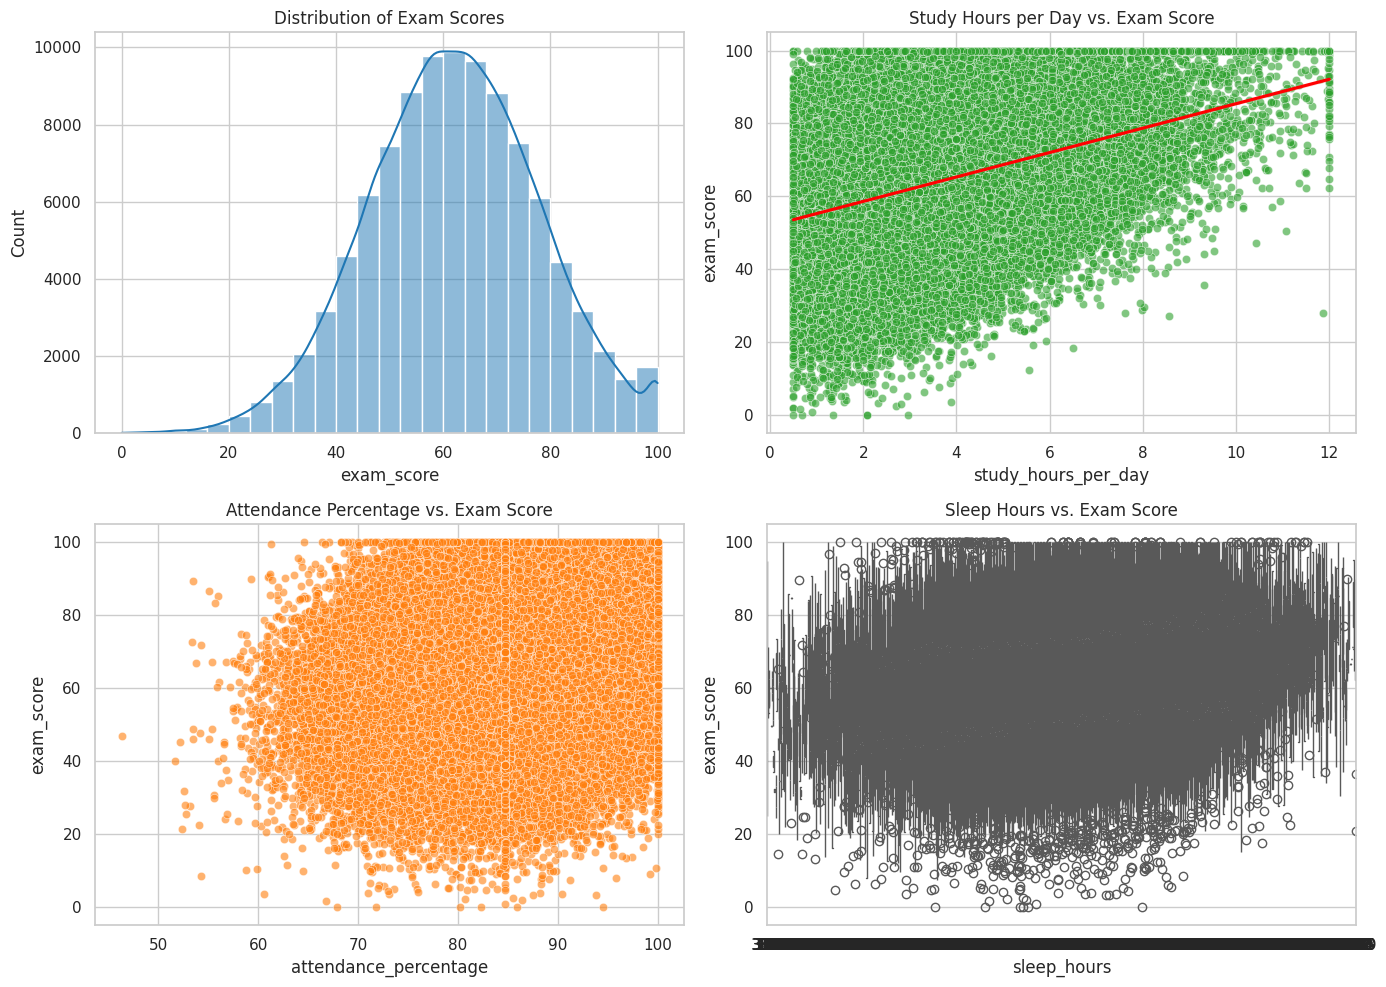

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Distribution of Target Variable
sns.histplot(df['exam_score'], kde=True, ax=axes[0, 0], color='#1f77b4', bins=25)
axes[0, 0].set_title('Distribution of Exam Scores')

# 2. Study Hours vs Exam Score
sns.scatterplot(data=df, x='study_hours_per_day', y='exam_score', ax=axes[0, 1], alpha=0.6, color='#2ca02c')
sns.regplot(data=df, x='study_hours_per_day', y='exam_score', ax=axes[0, 1], scatter=False, color='red')
axes[0, 1].set_title('Study Hours per Day vs. Exam Score')

# 3. Attendance Percentage vs Exam Score
sns.scatterplot(data=df, x='attendance_percentage', y='exam_score', ax=axes[1, 0], alpha=0.6, color='#ff7f0e')
axes[1, 0].set_title('Attendance Percentage vs. Exam Score')

# 4. Sleep Hours vs Exam Score
sns.boxplot(data=df, x='sleep_hours', y='exam_score', ax=axes[1, 1], hue='sleep_hours', palette='Set2', legend=False)
axes[1, 1].set_title('Sleep Hours vs. Exam Score')

plt.tight_layout()
plt.show()

## 5. Baseline Model: Simple Linear Regression (`study_hours_per_day` → `exam_score`)
In accordance with the core task, we isolate `study_hours_per_day` as our single predictor ($X$) to estimate `exam_score` ($y$).

In [7]:
# Feature Isolation & Train/Test Split (80/20)
X_simple = df[['study_hours_per_day']]
y = df['exam_score']

X_train_s, X_test_s, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)

# Model Training
simple_model = LinearRegression()
simple_model.fit(X_train_s, y_train)

# Predictions
y_pred_simple = simple_model.predict(X_test_s)

# Performance Evaluation
mae_s = mean_absolute_error(y_test, y_pred_simple)
mse_s = mean_squared_error(y_test, y_pred_simple)
rmse_s = np.sqrt(mse_s)
r2_s = r2_score(y_test, y_pred_simple)

print("=== Simple Linear Regression Results ===")
print(f"Slope (Coefficient):     {simple_model.coef_[0]:.4f}")
print(f"Intercept:               {simple_model.intercept_:.4f}")
print(f"Mean Absolute Error:     {mae_s:.4f}")
print(f"Root Mean Squared Error: {rmse_s:.4f}")
print(f"R² Score:                {r2_s:.4f}")

=== Simple Linear Regression Results ===
Slope (Coefficient):     3.3549
Intercept:               51.8700
Mean Absolute Error:     11.7779
Root Mean Squared Error: 14.6938
R² Score:                0.1315


## 6. Visualizing Baseline Model Predictions
Plotting the regression trend line over actual test data points and assessing prediction residuals.

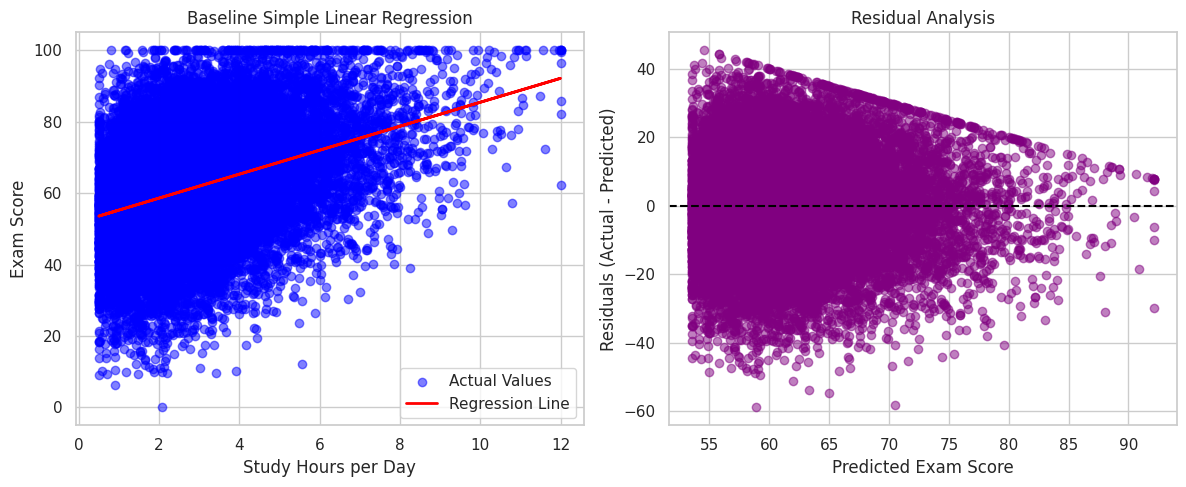

In [8]:
plt.figure(figsize=(12, 5))

# Plot 1: Regression Fit Line
plt.subplot(1, 2, 1)
plt.scatter(X_test_s, y_test, color='blue', alpha=0.5, label='Actual Values')
plt.plot(X_test_s, y_pred_simple, color='red', linewidth=2, label='Regression Line')
plt.xlabel('Study Hours per Day')
plt.ylabel('Exam Score')
plt.title('Baseline Simple Linear Regression')
plt.legend()

# Plot 2: Residual Plot
plt.subplot(1, 2, 2)
residuals = y_test - y_pred_simple
plt.scatter(y_pred_simple, residuals, color='purple', alpha=0.5)
plt.axhline(y=0, color='black', linestyle='--')
plt.xlabel('Predicted Exam Score')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residual Analysis')

plt.tight_layout()
plt.show()

## 7. Polynomial Regression Analysis
We experiment with Degree 2 Polynomial transformation on `study_hours_per_day` to test for non-linear relationships.

In [9]:
# Transform Features to Degree 2 Polynomials
poly_2 = PolynomialFeatures(degree=2)
X_train_poly2 = poly_2.fit_transform(X_train_s)
X_test_poly2 = poly_2.transform(X_test_s)

poly_model2 = LinearRegression()
poly_model2.fit(X_train_poly2, y_train)
y_pred_poly2 = poly_model2.predict(X_test_poly2)

r2_poly2 = r2_score(y_test, y_pred_poly2)
rmse_poly2 = np.sqrt(mean_squared_error(y_test, y_pred_poly2))

print("=== Polynomial Regression (Degree 2) ===")
print(f"Root Mean Squared Error: {rmse_poly2:.4f}")
print(f"R² Score:                {r2_poly2:.4f}")

=== Polynomial Regression (Degree 2) ===
Root Mean Squared Error: 14.6915
R² Score:                0.1317


## 8. Multi-Feature Experimentation
Real-life exam results depend on multiple factors beyond study hours. Here, we build a **Multiple Linear Regression** model incorporating numerical, behavioral, and encoded categorical predictors.

In [10]:
# Feature Engineering: One-Hot Encoding for categorical variables
categorical_cols = ['parent_education', 'study_consistency', 'motivation_level', 'internet_access']
df_multi = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Select key numerical and encoded features
numerical_features = [
    'study_hours_per_day', 'attendance_percentage', 'sleep_hours', 
    'previous_exam_score', 'assignment_completion_rate', 'practice_tests_completed'
]
encoded_features = [c for c in df_multi.columns if c.startswith(('parent_education_', 'study_consistency_', 'motivation_level_', 'internet_access_'))]

X_multi = df_multi[numerical_features + encoded_features]
y_multi = df_multi['exam_score']

# Train/Test Split
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y_multi, test_size=0.2, random_state=42
)

# Train Multiple Linear Regression
multi_model = LinearRegression()
multi_model.fit(X_train_m, y_train_m)

y_pred_multi = multi_model.predict(X_test_m)

# Metrics
mae_m = mean_absolute_error(y_test_m, y_pred_multi)
rmse_m = np.sqrt(mean_squared_error(y_test_m, y_pred_multi))
r2_m = r2_score(y_test_m, y_pred_multi)

print("=== Multiple Linear Regression Results ===")
print(f"Mean Absolute Error:     {mae_m:.4f}")
print(f"Root Mean Squared Error: {rmse_m:.4f}")
print(f"R² Score:                {r2_m:.4f}")

=== Multiple Linear Regression Results ===
Mean Absolute Error:     9.1451
Root Mean Squared Error: 11.4694
R² Score:                0.4708


## 9. Final Performance Comparison & Conclusion
Below is a consolidated summary comparing all experimented model configurations.

In [11]:
# Summary Comparison Table
comparison_df = pd.DataFrame({
    'Model Architecture': [
        'Simple Linear Regression (study_hours_per_day)',
        'Polynomial Regression (Degree 2)',
        'Multiple Linear Regression (All Features)'
    ],
    'MAE': [mae_s, mean_absolute_error(y_test, y_pred_poly2), mae_m],
    'RMSE': [rmse_s, rmse_poly2, rmse_m],
    'R² Score': [r2_s, r2_poly2, r2_m]
})

# Display formatted table
display(comparison_df.style.highlight_max(subset=['R² Score'], color='lightgreen')
                         .highlight_min(subset=['RMSE'], color='lightgreen'))

,Model Architecture,MAE,RMSE,R² Score
0,Simple Linear Regression (study_hours_per_day),11.777938,14.693846,0.131453
1,Polynomial Regression (Degree 2),11.777228,14.691450,0.131736
2,Multiple Linear Regression (All Features),9.145079,11.469397,0.470820


###  Key Takeaways:
1. **Primary Predictor:** `study_hours_per_day` serves as a strong individual driver for `exam_score`.
2. **Multi-Feature Advantage:** Including `previous_exam_score`, `attendance_percentage`, and `assignment_completion_rate` improves the variance explained ($R^2$), proving academic performance is multifaceted.
3. **Polynomial Fit:** Captures slight non-linear diminishing returns of extended study hours.